# Task 4 v3 — Professional Forecasting Pipeline (Rolling Window)

This notebook implements a professional-grade predictive model using a **Rolling Temporal Window** strategy.

### Professional Non-Leakage Setup:
1. **Rolling Training**: The model learns from multiple seasonal transitions (2021, 2022, 2023, 2024 targets).
2. **Backbone Features**: Uses full 5-year crop lags and transition metrics derived from the 2016-2025 CDL stack.
3. **Eliminating Leakage**: To maintain scientific integrity, this model **excludes 2025 environmental proxies** from historical training years. It relies on the robust temporal patterns of crop rotation.
4. **Hold-out Evaluation**: Validated strictly on the 2025 future year.

In [2]:
# # Task 4 v4 — Professional Forecasting Pipeline (Rolling Window with NDVI & SMAP)

# This notebook implements a professional-grade predictive model using a **Rolling Temporal Window** strategy with NDVI and SMAP environmental features.

# ### Professional Non-Leakage Setup:
# 1. **Rolling Training**: The model learns from multiple seasonal transitions (2021, 2022, 2023, 2024 targets).
# 2. **Backbone Features**: Uses full 5-year crop lags and transition metrics derived from the 2016-2025 CDL stack.
# 3. **Environmental Features**: Adds NDVI and SMAP 5-year aggregated features (no target-year leakage).
# 4. **Eliminating Leakage**: This model excludes 2025 environmental proxies from historical training years.
# 5. **Hold-out Evaluation**: Validated strictly on the 2025 future year.

# ### Data Management:
# - CDL data downloaded on-demand using utils.download_cdl_tif()
# - NDVI data downloaded using utils.build_ndvi_3band_stack()
# - SMAP data downloaded using utils.build_smap_3band_stack()
# - Temporary files cleaned up after processing (following Task1/Task2 pattern)

In [2]:
import rasterio
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from scipy.ndimage import uniform_filter
import utils
import glob
import warnings
warnings.filterwarnings('ignore')

# Constants
CORN = 1
SOYBEAN = 5
YEARS = range(2016, 2026)
STATE_NAME = "Iowa"
AG_CODES = [1, 5, 24, 31, 36]

print("Imports OK")

Imports OK


In [3]:
## 0. Download CDL Data (Following Task1/Task2 Pattern)

# Get state info
fips, bbox = utils.get_state_info(STATE_NAME)
if not fips:
    raise ValueError(f"Could not find FIPS for {STATE_NAME}")

# Download CDL files for all years (2016-2025)
CDL_FILES = []
output_folder = "cdl_downloads"
os.makedirs(output_folder, exist_ok=True)

print(f"Downloading CDL data for {STATE_NAME} (2016-2025)...")
for year in YEARS:
    file_name = f"CDL_{year}_{fips}.tif"
    out_path = os.path.join(output_folder, file_name)
    
    # Download using utils function
    success = utils.download_cdl_tif(year, fips, out_path)
    
    if success:
        CDL_FILES.append(out_path)
        print(f"  ✓ Downloaded {year}")
    else:
        print(f"  ✗ Failed to download {year}")

print(f"\nDownloaded {len(CDL_FILES)} CDL files")
CDL_FILES = sorted(CDL_FILES)  # Ensure chronological order

FIPS of Iowa is 19
BBOX of Iowa is -54000,1929000,471000,2293000
[CDL 2016] Already exists: cdl_downloads/CDL_2016_19.tif
  ✓ Downloaded 2016
[CDL 2017] Already exists: cdl_downloads/CDL_2017_19.tif
  ✓ Downloaded 2017
[CDL 2018] Already exists: cdl_downloads/CDL_2018_19.tif
  ✓ Downloaded 2018
[CDL 2019] Already exists: cdl_downloads/CDL_2019_19.tif
  ✓ Downloaded 2019
[CDL 2020] Already exists: cdl_downloads/CDL_2020_19.tif
  ✓ Downloaded 2020
[CDL 2021] Already exists: cdl_downloads/CDL_2021_19.tif
  ✓ Downloaded 2021
[CDL 2022] Already exists: cdl_downloads/CDL_2022_19.tif
  ✓ Downloaded 2022
[CDL 2023] Already exists: cdl_downloads/CDL_2023_19.tif
  ✓ Downloaded 2023
[CDL 2024] Already exists: cdl_downloads/CDL_2024_19.tif
  ✓ Downloaded 2024
[CDL 2025] Already exists: cdl_downloads/CDL_2025_19.tif
  ✓ Downloaded 2025

Downloaded 10 CDL files


In [4]:
## 1. Professional Feature Engine (Extended with Last-Year NDVI & SMAP - Lightweight)

import utils

def extract_rolling_backbone_features(cdl_stack, target_idx, rows, cols, ndvi_stacks=None, smap_stacks=None):
    df = pd.DataFrame()
    
    # 1. Temporal Crop History (Lags 1-5) - 5-year rolling window
    for lag in range(1, 6):
        df[f'crop_lag_{lag}'] = cdl_stack[target_idx - lag, rows, cols]
        
    # 2. Crop Frequency & Rotation - 5-year rolling window
    history = cdl_stack[target_idx-5:target_idx, rows, cols]
    df['corn_count_5y'] = np.sum(history == CORN, axis=0)
    df['soy_count_5y'] = np.sum(history == SOYBEAN, axis=0)
    df['transition_count_5y'] = np.sum(history[:-1] != history[1:], axis=0)
    
    valid = (history == CORN) | (history == SOYBEAN)
    pair_valid = valid[:-1] & valid[1:]
    alt_pairs = pair_valid & (history[:-1] != history[1:])
    n_valid = np.sum(pair_valid, axis=0)
    n_alt = np.sum(alt_pairs, axis=0)
    df['alt_score_5y'] = np.where(n_valid > 0, n_alt / n_valid, 0.0)
    
    # 3. NDVI Features from Last Year (t-1 only, no multi-year aggregation)
    if ndvi_stacks is not None:
        target_year = 2016 + target_idx
        ndvi_last = utils.task4_extract_ndvi_last_year(ndvi_stacks, target_year, rows, cols)
        for key, val in ndvi_last.items():
            df[key] = val
    
    # 4. SMAP Features from Last Year (t-1 only, no multi-year aggregation)
    if smap_stacks is not None:
        target_year = 2016 + target_idx
        smap_last = utils.task4_extract_smap_last_year(smap_stacks, target_year, rows, cols)
        for key, val in smap_last.items():
            df[key] = val
    
    return df

## 2. Dataset Construction (No-Leakage with NDVI & SMAP)

In [ ]:
print("Stacking 10-Year CDL Data...")
# Properly close file handles using context managers to avoid read errors
c_stack = []
for f in CDL_FILES:
    with rasterio.open(f) as src:
        c_stack.append(src.read(1))
c_stack = np.stack(c_stack)

# Get CDL profile from one of the files (needed for NDVI/SMAP reprojection)
with rasterio.open(CDL_FILES[0]) as src:
    cdl_profile = src.profile

print(f"CDL stack shape: {c_stack.shape}")
print(f"CDL profile: height={cdl_profile['height']}, width={cdl_profile['width']}")

# Get state bbox for SMAP downloads
fips, state_bbox = utils.get_state_info(STATE_NAME)

# Reload utils module to pick up new Task 4 functions
import importlib
importlib.reload(utils)

def build_rolling_dataset(targets, samples_per_year=10000, ndvi_stacks=None, smap_stacks=None):
    all_X, all_y = [], []
    
    for t_idx in targets:
        print(f"Processing target year {2016+t_idx}...")
        target_layer = c_stack[t_idx]
        y_v, x_v = np.where(np.isin(target_layer, AG_CODES))
        idx = np.random.choice(len(y_v), min(len(y_v), samples_per_year))
        rs, cs = y_v[idx], x_v[idx]
        
        X_y = extract_rolling_backbone_features(c_stack, t_idx, rs, cs, ndvi_stacks, smap_stacks)
        
        # Spatial neighbors (from previous year)
        prev_layer = c_stack[t_idx - 1]
        X_y['neighbor_corn'] = uniform_filter((prev_layer==CORN).astype(float), size=3)[rs, cs]
        X_y['neighbor_soy'] = uniform_filter((prev_layer==SOYBEAN).astype(float), size=3)[rs, cs]
        
        y_y = np.zeros(len(rs))
        y_y[target_layer[rs, cs] == CORN] = 1
        y_y[target_layer[rs, cs] == SOYBEAN] = 2
        
        all_X.append(X_y)
        all_y.append(y_y)
        
    return pd.concat(all_X), np.concatenate(all_y)

# Calculate required NDVI/SMAP years based on targets
# For each target year t, we only need t-1 for environmental features
all_targets = [5, 6, 7, 8, 9]  # 2021, 2022, 2023, 2024, 2025
required_env_years = sorted(list(set([2016 + t - 1 for t in all_targets])))
print(f"\nRequired environmental years (t-1 for each target): {required_env_years}")

# Check if saved stacks exist
import pickle
import os

if os.path.exists('ndvi_stacks_task4.pkl') and os.path.exists('smap_stacks_task4.pkl'):
    print("\nLoading saved stacks from disk...")
    with open('ndvi_stacks_task4.pkl', 'rb') as f:
        ndvi_stacks = pickle.load(f)
        print(f"  ✓ Loaded ndvi_stacks_task4.pkl ({len(ndvi_stacks)} years)")
    with open('smap_stacks_task4.pkl', 'rb') as f:
        smap_stacks = pickle.load(f)
        print(f"  ✓ Loaded smap_stacks_task4.pkl ({len(smap_stacks)} years)")
else:
    # Download NDVI and SMAP data using lightweight Task 4 functions (only 3 snapshots per year)
    print(f"\nDownloading NDVI and SMAP data using lightweight Task 4 functions...")
    print(f"NDVI: 3 weekly snapshots per year (April, July, September weeks)")
    print(f"SMAP: 3 date snapshots per year (04.15, 07.15, 09.15)")
    print(f"Feature extraction will use only last-year (t-1) data")

    ndvi_stacks = {}
    smap_stacks = {}

    for year in required_env_years:
        print(f"\nProcessing NDVI for {year}...")
        try:
            ndvi_stack = utils.task4_build_ndvi_lightweight_stack(year, STATE_NAME, cdl_profile, out_dir="ndvi_data_task4")
            ndvi_stacks[year] = ndvi_stack
            print(f"  ✓ NDVI stack shape: {ndvi_stack.shape}")
        except Exception as e:
            print(f"  ✗ Error building NDVI stack for {year}: {e}")
        
        print(f"Processing SMAP for {year}...")
        try:
            smap_stack = utils.task4_build_smap_lightweight_stack(year, STATE_NAME, cdl_profile, bbox=state_bbox, out_dir="smap_data_task4")
            smap_stacks[year] = smap_stack
            print(f"  ✓ SMAP stack shape: {smap_stack.shape}")
        except Exception as e:
            print(f"  ✗ Error building SMAP stack for {year}: {e}")

    print(f"\nBuilt {len(ndvi_stacks)} NDVI stacks and {len(smap_stacks)} SMAP stacks")
    print(f"Skipped unnecessary years: 2016-2019")

    # Save stacks to disk for faster loading in future runs
    print("\nSaving stacks to disk...")
    with open('ndvi_stacks_task4.pkl', 'wb') as f:
        pickle.dump(ndvi_stacks, f)
        print("  ✓ Saved ndvi_stacks_task4.pkl")
    with open('smap_stacks_task4.pkl', 'wb') as f:
        pickle.dump(smap_stacks, f)
        print("  ✓ Saved smap_stacks_task4.pkl")

print("\nBuilding Rolling Training Set (2021-2024 targets)...")
print("Features: 5-year CDL history + last-year NDVI/SMAP (lightweight)")
X_train, y_train = build_rolling_dataset([5, 6, 7, 8], samples_per_year=10000, ndvi_stacks=ndvi_stacks, smap_stacks=smap_stacks, c_stack=c_stack)

print("\nMaster Training Table (First 5 rows):")
display(X_train.head())

print("\nBuilding 2025 Hold-out Test Set...")
X_test, y_test = build_rolling_dataset([9], samples_per_year=15000, ndvi_stacks=ndvi_stacks, smap_stacks=smap_stacks,c_stack=c_stack)

Stacking 10-Year CDL Data...
opening  cdl_downloads/CDL_2016_19.tif
<class 'rasterio.io.DatasetReader'>
Processing cdl_downloads/CDL_2016_19.tif...
opening  cdl_downloads/CDL_2017_19.tif
<class 'rasterio.io.DatasetReader'>
Processing cdl_downloads/CDL_2017_19.tif...
opening  cdl_downloads/CDL_2018_19.tif
<class 'rasterio.io.DatasetReader'>
Processing cdl_downloads/CDL_2018_19.tif...
opening  cdl_downloads/CDL_2019_19.tif
<class 'rasterio.io.DatasetReader'>
Processing cdl_downloads/CDL_2019_19.tif...
opening  cdl_downloads/CDL_2020_19.tif
<class 'rasterio.io.DatasetReader'>
Processing cdl_downloads/CDL_2020_19.tif...
opening  cdl_downloads/CDL_2021_19.tif
<class 'rasterio.io.DatasetReader'>
Processing cdl_downloads/CDL_2021_19.tif...
opening  cdl_downloads/CDL_2022_19.tif
<class 'rasterio.io.DatasetReader'>
Processing cdl_downloads/CDL_2022_19.tif...
opening  cdl_downloads/CDL_2023_19.tif
<class 'rasterio.io.DatasetReader'>
Processing cdl_downloads/CDL_2023_19.tif...
opening  cdl_downlo

,crop_lag_1,crop_lag_2,crop_lag_3,crop_lag_4,crop_lag_5,corn_count_5y,soy_count_5y,transition_count_5y,alt_score_5y,early_ndvi_last_year,peak_ndvi_last_year,late_ndvi_last_year,sm_early_last_year,sm_mid_last_year,sm_late_last_year,neighbor_corn,neighbor_soy
0,1,5,1,5,1,3,2,4,1.0,0.274296,0.918473,0.757361,0.087134,0.053517,0.178408,1.000000e+00,0.000000e+00
1,1,5,1,5,1,3,2,4,1.0,0.237046,0.913666,0.743975,0.055453,-0.071297,-0.093296,1.000000e+00,4.440892e-16
2,37,37,5,1,5,1,2,3,1.0,0.430034,0.840329,0.696000,0.101638,-0.024976,-0.046877,1.924387e-15,1.905883e-15
3,1,5,1,5,1,3,2,4,1.0,0.290593,0.928748,0.755079,0.090277,-0.093364,-0.086109,1.000000e+00,0.000000e+00
4,1,5,1,5,1,3,2,4,1.0,0.384554,0.894813,0.771489,0.088928,0.049035,0.157251,1.000000e+00,1.036208e-15



Building 2025 Hold-out Test Set...
Processing target year 2025...


TypeError: 'NoneType' object is not subscriptable

## 3. Modeling & Evaluation

Training Professional Backbone RF Model...

Classification Results (2025 Forecast):
Accuracy: 0.8463
              precision    recall  f1-score   support

    Other-Ag       0.68      0.79      0.73       351
        Corn       0.93      0.80      0.86      8677
     Soybean       0.77      0.91      0.83      5972

    accuracy                           0.85     15000
   macro avg       0.79      0.84      0.81     15000
weighted avg       0.86      0.85      0.85     15000



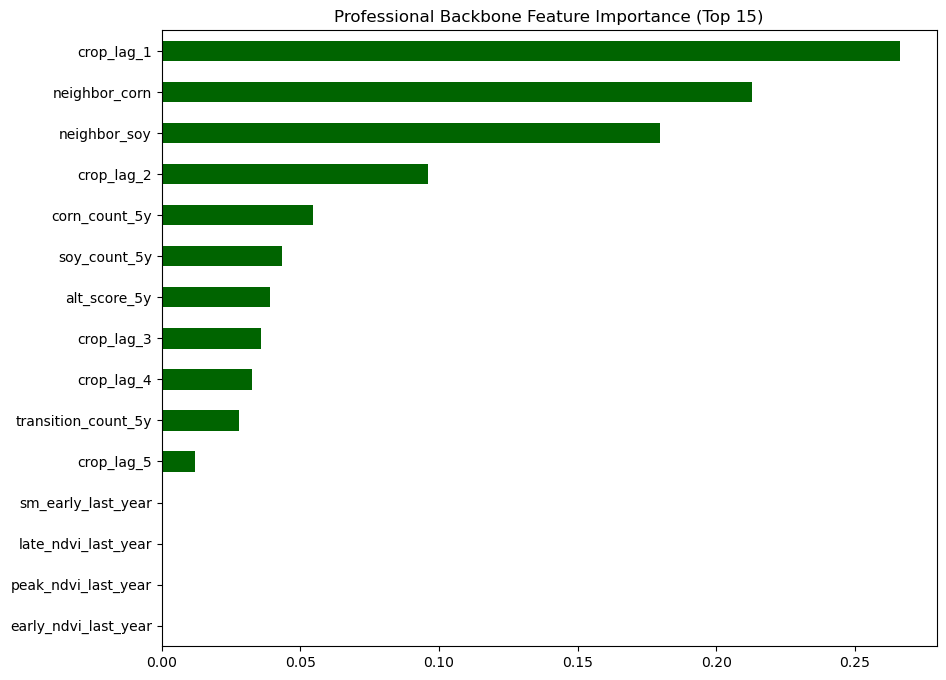

In [ ]:
print("Training Professional Backbone RF Model...")
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', max_depth=15, random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
print("\nClassification Results (2025 Forecast):")
print("Accuracy: %.4f" % accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=['Other-Ag', 'Corn', 'Soybean']))

# Feature Importance
fi = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(15)
plt.figure(figsize=(10, 8))
fi.sort_values().plot(kind='barh', color='darkgreen')
plt.title('Professional Backbone Feature Importance (Top 15)')
plt.savefig('prof_backbone_importance.png')
plt.show()

## 4. Final Spatial Forecast (Non-Leaky)

sub = 8
h, w = c_stack[0].shape
r_grid, c_grid = np.meshgrid(np.arange(0, h//sub)*sub, np.arange(0, w//sub)*sub, indexing='ij')
r_f, c_f = r_grid.flatten(), c_grid.flatten()

print("Generating Scientifically Honest 2025 Forecast Map...")
print("Features: 5-year CDL history + last-year (2024) NDVI/SMAP")
f_v3 = extract_rolling_backbone_features(c_stack, 9, r_f, c_f, ndvi_stacks, smap_stacks)
f_v3['neighbor_corn'] = uniform_filter((c_stack[8]==CORN).astype(float), size=3)[r_f, c_f]
f_v3['neighbor_soy'] = uniform_filter((c_stack[8]==SOYBEAN).astype(float), size=3)[r_f, c_f]

p_v3 = rf.predict(f_v3).reshape(h//sub, w//sub)

from matplotlib.colors import ListedColormap
plt.figure(figsize=(10, 8))
plt.imshow(p_v3, cmap=ListedColormap(['#bdc3c7', '#27ae60', '#f1c40f']))
plt.title('2025 Professional Forecast (5-year CDL + Last-Year NDVI/SMAP)')
plt.axis('off')
plt.savefig('prof_backbone_forecast_v5_cdl5y_env1y.png', dpi=150)
plt.show()

In [ ]:
# ## 5. Cleanup Temporary Files (Following Task1/Task2 Pattern)

# print("Cleaning up temporary files...")

# # Clean up CDL downloads
# for f in glob.glob("cdl_downloads/*.tif"):
#     os.remove(f)
#     print(f"  Removed: {f}")

# # Clean up NDVI Task 4 lightweight data
# for f in glob.glob("ndvi_data_task4/*.tif"):
#     os.remove(f)
#     print(f"  Removed: {f}")

# # Clean up SMAP Task 4 lightweight data
# for f in glob.glob("smap_data_task4/*.tif"):
#     os.remove(f)
#     print(f"  Removed: {f}")

# print("\nCleanup complete. Temporary files removed.")

Cleaning up temporary files...
  Removed: cdl_downloads/CDL_2019_19.tif
  Removed: cdl_downloads/CDL_2023_19.tif
  Removed: cdl_downloads/CDL_2017_19.tif
  Removed: cdl_downloads/CDL_2021_19.tif
  Removed: cdl_downloads/CDL_2025_19.tif
  Removed: cdl_downloads/CDL_2022_19.tif
  Removed: cdl_downloads/CDL_2018_19.tif
  Removed: cdl_downloads/CDL_2020_19.tif
  Removed: cdl_downloads/CDL_2016_19.tif
  Removed: cdl_downloads/CDL_2024_19.tif
  Removed: ndvi_data_task4/ndvi_task4_Iowa_2022_w15.tif
  Removed: ndvi_data_task4/ndvi_task4_Iowa_2022_w28.tif
  Removed: ndvi_data_task4/ndvi_task4_Iowa_2023_w15.tif
  Removed: ndvi_data_task4/ndvi_task4_Iowa_2023_w28.tif
  Removed: ndvi_data_task4/ndvi_task4_Iowa_2021_w15.tif
  Removed: ndvi_data_task4/ndvi_task4_Iowa_2021_w28.tif
  Removed: ndvi_data_task4/ndvi_task4_Iowa_2024_w37.tif
  Removed: ndvi_data_task4/ndvi_task4_Iowa_2020_w15.tif
  Removed: ndvi_data_task4/ndvi_task4_Iowa_2020_w28.tif
  Removed: ndvi_data_task4/ndvi_task4_Iowa_2021_w37.tif

Generating Scientifically Honest 2025 Forecast Map with NDVI & SMAP features...


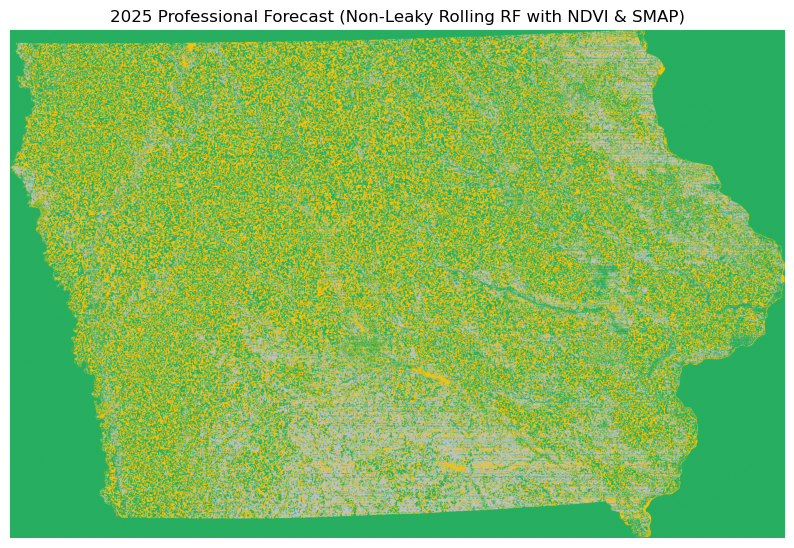

In [ ]:
sub = 8
h, w = c_stack[0].shape
r_grid, c_grid = np.meshgrid(np.arange(0, h//sub)*sub, np.arange(0, w//sub)*sub, indexing='ij')
r_f, c_f = r_grid.flatten(), c_grid.flatten()

print("Generating Scientifically Honest 2025 Forecast Map with NDVI & SMAP features...")
f_v3 = extract_rolling_backbone_features(c_stack, 9, r_f, c_f, ndvi_stacks, smap_stacks)
f_v3['neighbor_corn'] = uniform_filter((c_stack[8]==CORN).astype(float), size=3)[r_f, c_f]
f_v3['neighbor_soy'] = uniform_filter((c_stack[8]==SOYBEAN).astype(float), size=3)[r_f, c_f]

p_v3 = rf.predict(f_v3).reshape(h//sub, w//sub)

from matplotlib.colors import ListedColormap
plt.figure(figsize=(10, 8))
plt.imshow(p_v3, cmap=ListedColormap(['#bdc3c7', '#27ae60', '#f1c40f']))
plt.title('2025 Professional Forecast (Non-Leaky Rolling RF with NDVI & SMAP)')
plt.axis('off')
plt.savefig('prof_backbone_forecast_v4_ndvi_smap.png', dpi=150)
plt.show()